# Hito 3 — Réplica del enfoque ganador IJCB 2026

Este cuaderno implementa una aproximación al sistema presentado por el equipo Incode en la pista 1 del reto IJCB PAD-ID Card 2026, que obtuvo el primer puesto con un AVRank del 27,82 %. El objetivo no es reproducir el resultado exacto del challenge —algo imposible sin acceso a sus datos sintéticos propietarios— sino evaluar en qué medida las innovaciones arquitectónicas explican su ventaja frente a las arquitecturas convencionales del Hito 2.

Los componentes replicados son: backbone ConvNeXt-Base con pesos ImageNet-21K, clasificación mediante cuatro cabezas sigmoid independientes (bonafide, print, screen y composite), entrada dual con imagen recortada e imagen con más contexto, función de puntuación Incode S = clamp(½(P_bonafide − max P_ataques + 1), 0, 1), y Test-Time Augmentation con cuatro vistas en inferencia.

No se replican los datos SPAS (FLUX Klein 9B, propietarios) ni el ensemble de folds sobre la partición privada del challenge. Cualquier diferencia de rendimiento respecto al resultado oficial debe interpretarse en ese contexto.

**Referencia:** IJCB PAD-ID Card 2026 Challenge — Track 1, equipo Incode. AVRank = 27,82 %.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
# timm suele estar ya disponible si se ejecutó el notebook de experimentos
# en la misma sesión; se instala de nuevo por si el runtime es nuevo.
subprocess.run(['pip', 'install', 'timm', '--quiet'], check=True)
print('Dependencias listas.')


Mounted at /content/drive
Dependencias listas.


In [2]:
import os, gc, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import det_curve, roc_curve

warnings.filterwarnings('ignore')


def setup_device():
    import subprocess as sp
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        r = sp.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True)
        print(f'GPU: {r.stdout.strip()}')
    else:
        warnings.warn('Sin GPU — el entrenamiento será muy lento.', RuntimeWarning)
    return device


def set_reproducibility(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


DEVICE = setup_device()
print(f'PyTorch {torch.__version__} | timm {timm.__version__}')


GPU: NVIDIA A100-SXM4-40GB, 40960 MiB
PyTorch 2.11.0+cu128 | timm 1.0.27


In [3]:
# Rutas en Google Drive (misma estructura que el cuaderno de experimentos)
DRIVE_ROOT  = Path('/content/drive/MyDrive/TFM_ID_Cards')
PKL_PATH    = DRIVE_ROOT / 'pickles' / 'df_cross.pkl'
SEG_DIR     = DRIVE_ROOT / 'segmentado'
OUTPUT_DIR  = DRIVE_ROOT / 'hito3' / 'incode_replica'
CKPT_DIR    = OUTPUT_DIR / 'checkpoints'
RESULT_DIR  = OUTPUT_DIR / 'resultados'
for d in [OUTPUT_DIR, CKPT_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Clases y mapeo (mismo orden que en el cuaderno de experimentos)
CLASS_NAMES = ['bonafide', 'print', 'screen', 'composite']
LABEL_MAP   = {'bonafide': 0, 'print': 1, 'printed': 1, 'screen': 2, 'composite': 3}

CONFIG = {
    # Backbone: ConvNeXt-Base con pesos ImageNet-21K (lo más cercano al
    # backbone del equipo Incode, que usa pesos propietarios DINOv3)
    'backbone'     : 'convnext_base.fb_in22k_ft_in1k',
    'feat_dim'     : 1024,   # dimensión de salida de ConvNeXt-Base
    'num_classes'  : 4,      # bonafide, print, screen, composite

    # Entrada dual:
    #   pad_crop = 5 %  → equivale al margen que añade YOLOv11n tras detección
    #   pad_full = 20 % → aproxima la imagen completa con más contexto de fondo
    'pad_crop'     : 0.05,
    'pad_full'     : 0.20,

    # Cabeza clasificadora
    'head_hidden'  : 512,
    'head_dropout' : 0.3,

    # Entrenamiento
    'img_size'     : 224,
    'batch_size'   : 32,
    'epochs'       : 60,
    'patience'     : 15,
    'lr'           : 3e-5,
    'weight_decay' : 1e-2,
    'grad_clip'    : 1.0,
    'num_workers'  : 4,
    'run_seeds'    : [0, 1, 2],

    # TTA en inferencia (4 vistas: original, flip H, rot +90, rot -90)
    'tta'          : True,
}

print('Configuración lista.')
print(f'  Backbone  : {CONFIG["backbone"]}')
print(f'  Clases    : {CLASS_NAMES}')
print(f'  Épocas    : {CONFIG["epochs"]}  |  patience: {CONFIG["patience"]}')
print(f'  Seeds     : {CONFIG["run_seeds"]}')


Configuración lista.
  Backbone  : convnext_base.fb_in22k_ft_in1k
  Clases    : ['bonafide', 'print', 'screen', 'composite']
  Épocas    : 60  |  patience: 15
  Seeds     : [0, 1, 2]


In [4]:
print('=' * 62)
print('  VERIFICACIÓN PREVIA AL ENTRENAMIENTO')
print('=' * 62)

# GPU
if torch.cuda.is_available():
    gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  GPU     : {torch.cuda.get_device_name(0)}  ({gb:.1f} GB)')
else:
    print('  AVISO   : No hay GPU. Cambia el Runtime a GPU antes de entrenar.')

# Pickle
if PKL_PATH.exists():
    _df = pd.read_pickle(str(PKL_PATH))
    print(f'  Pickle  : {len(_df):,} filas  |  columnas: {list(_df.columns)}')
    if 'tipo' in _df.columns:
        print('  Tipos de ataque encontrados en la columna tipo:')
        for val, cnt in _df['tipo'].value_counts().items():
            print(f'    {val:<20} {cnt:>6} muestras')
    del _df
else:
    print(f'  ERROR   : Pickle no encontrado en {PKL_PATH}')

# Imágenes segmentadas
if SEG_DIR.exists():
    n = sum(1 for _ in SEG_DIR.rglob('*.jpg')) + sum(1 for _ in SEG_DIR.rglob('*.png'))
    print(f'  Imágenes : {n:,} archivos en {SEG_DIR.name}/')
else:
    print(f'  ERROR   : Directorio segmentado no encontrado: {SEG_DIR}')

# Estado de runs previos
print(f'  Runs en {RESULT_DIR.relative_to(DRIVE_ROOT)}:')
for seed in CONFIG['run_seeds']:
    rp = RESULT_DIR / f'run{seed}.json'
    estado = 'COMPLETO' if rp.exists() else 'Pendiente'
    print(f'    seed={seed}  {estado}')

print('=' * 62)


  VERIFICACIÓN PREVIA AL ENTRENAMIENTO
  GPU     : NVIDIA A100-SXM4-40GB  (42.4 GB)
  Pickle  : 26,565 filas  |  columnas: ['ruta', 'tipo', 'etiqueta_binaria', 'document_id', 'source', 'split', 'country']
  Tipos de ataque encontrados en la columna tipo:
    screen                 8080 muestras
    print                  6391 muestras
    bonafide               6045 muestras
    printed                3049 muestras
    composite              3000 muestras
  Imágenes : 26,565 archivos en segmentado/
  Runs en hito3/incode_replica/resultados:
    seed=0  COMPLETO
    seed=1  COMPLETO
    seed=2  COMPLETO


In [5]:
def _remap_paths(dataframe, seg_dir):
    """Ajusta rutas locales a las rutas reales en Google Drive."""
    if len(dataframe) > 0 and os.path.exists(dataframe['ruta'].iloc[0]):
        return dataframe
    index  = {f.name: str(f) for f in seg_dir.rglob('*') if f.is_file()}
    result = dataframe.copy()
    result['ruta'] = result['ruta'].apply(lambda p: index.get(Path(p).name, p))
    n_ok = result['ruta'].apply(os.path.exists).sum()
    print(f'Rutas remapeadas: {n_ok}/{len(result)} válidas')
    if n_ok < len(result) * 0.95:
        warnings.warn(f'Solo {n_ok}/{len(result)} rutas resueltas. Revisa SEG_DIR.')
    return result


print('Cargando datos desde Drive...')
df_cross = pd.read_pickle(str(PKL_PATH))

if 'etiqueta_multi' not in df_cross.columns:
    df_cross['etiqueta_multi'] = df_cross['tipo'].map(LABEL_MAP).astype(int)

if 'source' not in df_cross.columns:
    df_cross['source'] = df_cross['document_id'].apply(
        lambda d: 'idcards' if str(d).startswith('idc_') else 'synpass')

df_cross = _remap_paths(df_cross, SEG_DIR)

TRAIN_DF = df_cross[df_cross['split'] == 'train'].reset_index(drop=True)
VAL_DF   = df_cross[df_cross['split'] == 'val'].reset_index(drop=True)
TEST_DF  = df_cross[df_cross['split'].isin(['test_syn', 'test'])].reset_index(drop=True)

print(f'Train : {len(TRAIN_DF):,}  |  Val : {len(VAL_DF):,}  |  Test : {len(TEST_DF):,}')
print('Distribución train por clase:')
for i, name in enumerate(CLASS_NAMES):
    cnt = (TRAIN_DF['etiqueta_multi'] == i).sum()
    print(f'  {name:<14}: {cnt:>6}')


Cargando datos desde Drive...
Train : 13,372  |  Val : 6,805  |  Test : 6,388
Distribución train por clase:
  bonafide      :   3337
  print         :   4332
  screen        :   3316
  composite     :   2387


## Dataset con entrada dual

El equipo Incode alimenta su modelo con dos vistas de cada documento: la imagen recortada con un margen del 5 % (equivalente al que añade YOLOv11n tras la detección del documento) y la imagen completa con contexto de fondo. Dado que en este trabajo solo se dispone de las imágenes ya segmentadas por SAM, la vista completa se aproxima añadiendo un padding reflejado del 20 %, que preserva más información del entorno del documento sin distorsionar la textura de sus bordes. Ambas vistas se procesan con el mismo backbone (pesos compartidos) y sus representaciones se concatenan antes de la cabeza clasificadora.

In [6]:
def _seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)


def build_transforms(img_size, augment=False):
    mu = [0.485, 0.456, 0.406]; sg = [0.229, 0.224, 0.225]
    if augment:
        return A.Compose([
            A.RandomResizedCrop(size=(img_size, img_size), scale=(0.7, 1.0), p=1.0),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.15, hue=0.05, p=0.6),
            A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
            A.Normalize(mean=mu, std=sg), ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.Normalize(mean=mu, std=sg), ToTensorV2(),
    ])


def build_tta_transforms(img_size):
    """Cuatro vistas para TTA: original, flip horizontal, rot +90 y rot -90."""
    mu = [0.485, 0.456, 0.406]; sg = [0.229, 0.224, 0.225]
    base = [A.Resize(height=img_size, width=img_size), A.Normalize(mean=mu, std=sg), ToTensorV2()]
    return [
        A.Compose(base),
        A.Compose([A.HorizontalFlip(p=1.0)] + base),
        A.Compose([A.VerticalFlip(p=1.0)] + base),
        A.Compose([A.HorizontalFlip(p=1.0), A.VerticalFlip(p=1.0)] + base),
    ]


class PADDualDataset(Dataset):
    """Dataset PAD con entrada dual: imagen recortada (pad_crop) e imagen con
    más contexto (pad_full).

    La rama crop aproxima el recorte YOLOv11n+5 % del equipo Incode.
    La rama full preserva más información de fondo mediante padding reflejado.
    Las etiquetas se devuelven en formato multiclase (0–3) para aplicar
    one-hot en el bucle de entrenamiento y calcular la BCE multilabel.
    """
    def __init__(self, dataframe, transform, pad_crop=0.05, pad_full=0.20):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.pad_crop  = pad_crop
        self.pad_full  = pad_full
        self.paths     = self.df['ruta'].tolist()
        self.labels    = self.df['etiqueta_multi'].tolist()
        self.types     = self.df['tipo'].tolist()

    def __len__(self):
        return len(self.df)

    @staticmethod
    def _pad(img, frac):
        h, w = img.shape[:2]
        ph, pw = int(h * frac), int(w * frac)
        return np.pad(img, ((ph, ph), (pw, pw), (0, 0)), mode='reflect')

    def __getitem__(self, idx):
        try:
            base = np.array(Image.open(self.paths[idx]).convert('RGB'))
        except Exception:
            base = np.zeros((224, 224, 3), dtype=np.uint8)
        img_crop = self._pad(base, self.pad_crop)
        img_full = self._pad(base, self.pad_full)
        x_crop = self.transform(image=img_crop)['image']
        x_full = self.transform(image=img_full)['image']
        return x_crop, x_full, self.labels[idx], self.types[idx]


def _class_weights_and_sampler(labels, num_classes, seed):
    counts   = np.bincount(labels, minlength=num_classes).astype(float)
    inv_freq = 1.0 / (counts + 1e-6)
    sw       = [float(inv_freq[l]) for l in labels]
    sampler  = WeightedRandomSampler(
        weights=sw, num_samples=len(sw), replacement=True,
        generator=torch.Generator().manual_seed(seed))
    return sampler


def build_dataloaders(train_df, val_df, test_df, config, seed):
    sz      = config['img_size']
    tfm_tr  = build_transforms(sz, augment=True)
    tfm_val = build_transforms(sz, augment=False)
    pc = config['pad_crop']; pf = config['pad_full']
    ds_train = PADDualDataset(train_df, tfm_tr,  pad_crop=pc, pad_full=pf)
    ds_val   = PADDualDataset(val_df,   tfm_val, pad_crop=pc, pad_full=pf)
    ds_test  = PADDualDataset(test_df,  tfm_val, pad_crop=pc, pad_full=pf)
    sampler  = _class_weights_and_sampler(train_df['etiqueta_multi'].tolist(), 4, seed)
    kw = dict(num_workers=config['num_workers'], pin_memory=True)
    return (
        DataLoader(ds_train, batch_size=config['batch_size'],
                   sampler=sampler, worker_init_fn=_seed_worker, **kw),
        DataLoader(ds_val,  batch_size=config['batch_size'] * 2,
                   shuffle=False, **kw),
        DataLoader(ds_test, batch_size=config['batch_size'] * 2,
                   shuffle=False, **kw),
    )

print('Dataset y DataLoaders definidos.')

Dataset y DataLoaders definidos.


## Modelo: ConvNeXt-Base con cuatro cabezas sigmoid independientes

La diferencia fundamental entre el enfoque Incode y los modelos del Hito 2 no es el backbone sino la formulación del problema de clasificación. En lugar de un softmax de cuatro clases que obliga a distribuir la probabilidad entre ellas, cada clase tiene su propia cabeza sigmoid entrenada de forma independiente con Binary Cross-Entropy. Esto permite que el modelo detecte varias características simultáneamente, lo que es especialmente relevante para los ataques compuestos: en un esquema softmax, la señal de impresión y la de pantalla se neutralizan mutuamente; con cabezas independientes, ambas pueden activarse a la vez y contribuir a la puntuación final.

El backbone ConvNeXt-Base produce 1 024 características por rama. Las dos ramas (crop y full) se concatenan en 2 048 dimensiones antes de la cabeza clasificadora. Se liberan las dos últimas etapas del backbone y se congelan el stem y las dos primeras etapas, lo que reduce los parámetros entrenables a menos del 50 %.

In [7]:
class DualInputConvNeXt(nn.Module):
    """ConvNeXt-Base de entrada dual con cuatro cabezas sigmoid independientes.

    La rama crop y la rama full comparten pesos del backbone. Las representaciones
    de ambas ramas se concatenan antes de pasar por la cabeza clasificadora.
    La salida son logits crudos (sin sigmoid); el sigmoid se aplica en la
    función de score y en la función de pérdida.
    """
    def __init__(self, backbone_name, feat_dim, num_classes,
                 head_hidden, head_dropout):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0, global_pool='avg')

        # Congelar stem y etapas 0 y 1; liberar etapas 2 y 3
        for p in self.backbone.parameters():
            p.requires_grad = False
        for name, p in self.backbone.named_parameters():
            if any(s in name for s in ['stages.2', 'stages.3', 'norm_pre']):
                p.requires_grad = True

        self.head = nn.Sequential(
            nn.Linear(feat_dim * 2, head_hidden),
            nn.BatchNorm1d(head_hidden),
            nn.Dropout(p=head_dropout),
            nn.GELU(),
            nn.Linear(head_hidden, num_classes),
        )

    def forward(self, x_crop, x_full):
        f_crop = self.backbone(x_crop)            # (B, 1024)
        f_full = self.backbone(x_full)            # (B, 1024)
        feat   = torch.cat([f_crop, f_full], 1)  # (B, 2048)
        return self.head(feat)                    # (B, 4) logits


def build_incode_model(config, run_seed):
    set_reproducibility(run_seed)
    model = DualInputConvNeXt(
        backbone_name = config['backbone'],
        feat_dim      = config['feat_dim'],
        num_classes   = config['num_classes'],
        head_hidden   = config['head_hidden'],
        head_dropout  = config['head_dropout'],
    ).to(DEVICE)
    tot = sum(p.numel() for p in model.parameters())
    tra = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  DualInputConvNeXt : {tra:,} entrenables / {tot:,} total '
          f'({100 * tra / tot:.1f} %)')
    return model


# Comprobación rápida de construcción
_m = build_incode_model(CONFIG, run_seed=0)
del _m; torch.cuda.empty_cache()
print('Modelo verificado correctamente.')


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

  DualInputConvNeXt : 86,445,572 entrenables / 88,618,628 total (97.5 %)
Modelo verificado correctamente.


In [8]:
def incode_score(logits):
    """Fórmula de puntuación del equipo Incode (IJCB 2026 Track 1).

    S = clamp( 0.5 * (P_bonafide - max_i P_ataque_i + 1.0), 0.0, 1.0 )

    Un valor de S alto indica documento probablemente auténtico.
    El score de ataque que reciben las métricas PAD es (1 - S).
    """
    probs = torch.sigmoid(logits.float())      # (B, 4)
    p_bon = probs[:, 0]                        # bonafide
    p_atk = probs[:, 1:].max(dim=1).values    # max(print, screen, composite)
    return (0.5 * (p_bon - p_atk + 1.0)).clamp(0.0, 1.0)


def _compute_eer(labels, scores):
    fpr, fnr, _ = det_curve(labels, scores, pos_label=1)
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)


def _bpcer_at_apcer(labels, scores, target_apcer):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    valid = np.where((1.0 - tpr) <= target_apcer)[0]
    return float(fpr[valid[0]]) if len(valid) > 0 else 1.0


def compute_pad_metrics(labels_binary, scores, name='', verbose=True):
    nan_d = {k: float('nan') for k in
             ['EER', 'APCER', 'BPCER',
              'BPCER@APCER10', 'BPCER@APCER5', 'BPCER@APCER1', 'AVRank']}
    if len(np.unique(labels_binary)) < 2:
        warnings.warn(f'[{name}] Solo una clase presente.'); return nan_d
    eer   = _compute_eer(labels_binary, scores)
    b10   = _bpcer_at_apcer(labels_binary, scores, 0.10)
    b5    = _bpcer_at_apcer(labels_binary, scores, 0.05)
    b1    = _bpcer_at_apcer(labels_binary, scores, 0.01)
    av    = 0.2 * b10 + 0.3 * b5 + 0.5 * b1
    preds = (scores >= 0.5).astype(int)
    is_atk = labels_binary == 1; is_gen = labels_binary == 0
    apcer = float(np.sum((preds == 0) & is_atk) / max(is_atk.sum(), 1))
    bpcer = float(np.sum((preds == 1) & is_gen) / max(is_gen.sum(), 1))
    metrics = {
        'EER': eer, 'APCER': apcer, 'BPCER': bpcer,
        'BPCER@APCER10': b10, 'BPCER@APCER5': b5,
        'BPCER@APCER1': b1,  'AVRank': av,
    }
    if verbose:
        pref = f'[{name}] ' if name else ''
        for k, v in metrics.items():
            print(f'  {pref}{k:<18} {v:.4f}')
    return metrics


def evaluate_incode(model, loader, label='', verbose=True):
    model.eval()
    all_scores, all_labels, all_types = [], [], []
    with torch.no_grad():
        for x_crop, x_full, multi_labels, atk_types in \
                tqdm(loader, desc=f'Eval {label}', leave=False):
            x_crop = x_crop.to(DEVICE, non_blocking=True)
            x_full = x_full.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(x_crop, x_full)
            S = incode_score(logits)
            all_scores.extend((1.0 - S).cpu().numpy())
            all_labels.extend((multi_labels != 0).long().numpy())
            all_types.extend(atk_types)
    sc = np.array(all_scores)
    lb = np.array(all_labels)
    tp = np.array(all_types)
    metrics = compute_pad_metrics(lb, sc, name=label, verbose=verbose)
    if verbose:
        for t in sorted(x for x in np.unique(tp) if x != 'bonafide'):
            mask = tp == t; atk = lb[mask] == 1
            if atk.sum() == 0: continue
            pred = (sc[mask] >= 0.5).astype(int)
            apcer_t = np.sum((pred == 0) & atk) / atk.sum()
            print(f'    {t:<16}: APCER={apcer_t:.4f}  (n={atk.sum()})')
    return metrics


def evaluate_incode_tta(model, df, tta_transforms, config, label='', verbose=True):
    """TTA: promedia los scores de cuatro vistas aumentadas."""
    pc = config['pad_crop']; pf = config['pad_full']
    all_scores_list = []
    ref_labels = ref_types = None
    model.eval()
    for tfm in tta_transforms:
        ds     = PADDualDataset(df, tfm, pad_crop=pc, pad_full=pf)
        loader = DataLoader(
            ds, batch_size=config['batch_size'] * 2, shuffle=False,
            num_workers=config['num_workers'], pin_memory=True)
        scores, labels, types = [], [], []
        with torch.no_grad():
            for x_crop, x_full, ml, tp in loader:
                x_crop = x_crop.to(DEVICE); x_full = x_full.to(DEVICE)
                with torch.amp.autocast('cuda'):
                    logits = model(x_crop, x_full)
                S = incode_score(logits)
                scores.extend((1.0 - S).cpu().numpy())
                labels.extend((ml != 0).long().numpy())
                types.extend(tp)
        all_scores_list.append(np.array(scores))
        if ref_labels is None:
            ref_labels = np.array(labels)
            ref_types  = np.array(types)
    avg_scores = np.mean(all_scores_list, axis=0)
    return compute_pad_metrics(
        ref_labels, avg_scores,
        name=f'{label} (TTA x{len(tta_transforms)})', verbose=verbose)


def aggregate_runs(run_metrics):
    return {k: {'mean': float(np.nanmean([m[k] for m in run_metrics])),
                'std':  float(np.nanstd( [m[k] for m in run_metrics], ddof=1))}
            for k in run_metrics[0].keys()}


print('Función de score Incode y métricas PAD definidas.')


Función de score Incode y métricas PAD definidas.


In [9]:
def train_incode(model, train_loader, val_loader, config, ckpt_dir, run_seed):
    """Entrena el modelo con BCE multilabel, AdamW y cosine annealing.

    Guarda el mejor checkpoint (menor EER en validación) y un checkpoint de
    reanudación cada cinco épocas para tolerar desconexiones del runtime.
    """
    optimizer  = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=config['lr'] * 0.01)
    criterion  = nn.BCEWithLogitsLoss()
    scaler     = torch.cuda.amp.GradScaler()

    best_eer     = float('inf')
    patience_cnt = 0
    history      = {'train_loss': [], 'val_eer': []}
    ckpt_best    = ckpt_dir / f'best_run{run_seed}.pt'
    ckpt_resume  = ckpt_dir / f'resume_run{run_seed}.pt'

    # Reanudar si existe checkpoint de reanudación
    start_epoch = 0
    if ckpt_resume.exists():
        state = torch.load(str(ckpt_resume), map_location=DEVICE, weights_only=False)
        model.load_state_dict(state['model_state_dict'])
        optimizer.load_state_dict(state['optimizer_state_dict'])
        scheduler.load_state_dict(state['scheduler_state_dict'])
        start_epoch  = state['epoch'] + 1
        best_eer     = state.get('best_eer', float('inf'))
        history      = state.get('history', history)
        patience_cnt = state.get('patience_cnt', 0)
        print(f'  Reanudando desde época {start_epoch} '
              f'(mejor EER val hasta ahora = {best_eer:.4f})')

    for epoch in range(start_epoch, config['epochs']):
        model.train()
        total_loss = 0.0
        for x_crop, x_full, multi_labels, _ in tqdm(
                train_loader,
                desc=f'Ep {epoch + 1}/{config["epochs"]}  seed={run_seed}',
                leave=False):
            x_crop  = x_crop.to(DEVICE, non_blocking=True)
            x_full  = x_full.to(DEVICE, non_blocking=True)
            targets = F.one_hot(multi_labels, num_classes=4).float().to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                logits = model(x_crop, x_full)
                loss   = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / len(train_loader)

        val_metrics = evaluate_incode(
            model, val_loader, label='val', verbose=False)
        val_eer = val_metrics['EER']
        history['train_loss'].append(avg_loss)
        history['val_eer'].append(val_eer)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f'  Ep {epoch + 1:>3}  '
                  f'loss={avg_loss:.4f}  '
                  f'val_EER={val_eer:.4f}  '
                  f'lr={lr_now:.2e}')

        # Mejor checkpoint
        if val_eer < best_eer:
            best_eer = val_eer; patience_cnt = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_eer': val_eer,
                        'history': history}, str(ckpt_best))
        else:
            patience_cnt += 1

        # Checkpoint de reanudación (cada 5 épocas)
        if (epoch + 1) % 5 == 0:
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'best_eer': best_eer,
                        'history': history,
                        'patience_cnt': patience_cnt}, str(ckpt_resume))

        if patience_cnt >= config['patience']:
            print(f'  Early stopping en época {epoch + 1}.')
            break

    return history, best_eer

print('Bucle de entrenamiento definido.')


Bucle de entrenamiento definido.


## Entrenamiento con tres semillas

Se ejecutan tres semillas para obtener una estimación estable del rendimiento y calcular la desviación típica entre runs. El mejor checkpoint de cada semilla se guarda según el EER en validación. Si el runtime de Colab se desconecta durante el entrenamiento, la siguiente ejecución de esta celda retomará automáticamente desde el último checkpoint de reanudación, que se guarda cada cinco épocas. Al finalizar cada run se evaluan el split de validación (ID Cards) y el de test (SYN PASS), con y sin TTA.

In [10]:
TTA_TRANSFORMS = build_tta_transforms(CONFIG['img_size'])
ALL_RESULTS    = []

for seed in CONFIG['run_seeds']:
    print(f'\n{"=" * 62}')
    print(f'  RUN  SEED = {seed}')
    print(f'{"=" * 62}')

    result_path = RESULT_DIR / f'run{seed}.json'
    if result_path.exists():
        print('  Run ya completado. Cargando resultados guardados.')
        with open(result_path) as f:
            ALL_RESULTS.append(json.load(f))
        continue

    set_reproducibility(seed)
    model = build_incode_model(CONFIG, run_seed=seed)
    train_loader, val_loader, test_loader = \
        build_dataloaders(TRAIN_DF, VAL_DF, TEST_DF, CONFIG, seed)

    history, best_val_eer = train_incode(
        model, train_loader, val_loader, CONFIG, CKPT_DIR, seed)

    # Cargar mejor checkpoint para la evaluación final
    ckpt_best = CKPT_DIR / f'best_run{seed}.pt'
    model.load_state_dict(
        torch.load(str(ckpt_best), map_location=DEVICE,
                   weights_only=False)['model_state_dict'])

    print(f'\n--- Evaluación VAL (ID Cards) ---')
    val_metrics  = evaluate_incode(model, val_loader,
                                   label='Val', verbose=True)

    print(f'\n--- Evaluación TEST (SYN PASS) ---')
    test_metrics = evaluate_incode(model, test_loader,
                                   label='Test', verbose=True)

    test_tta_metrics = {}
    if CONFIG['tta']:
        print(f'\n--- Evaluación TEST con TTA ({len(TTA_TRANSFORMS)} vistas) ---')
        test_tta_metrics = evaluate_incode_tta(
            model, TEST_DF, TTA_TRANSFORMS, CONFIG,
            label='Test', verbose=True)

    result = {
        'run_seed'     : seed,
        'best_val_eer' : best_val_eer,
        'val'          : val_metrics,
        'test'         : test_metrics,
        'test_tta'     : test_tta_metrics,
    }
    ALL_RESULTS.append(result)
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    print(f'\n  Run {seed} guardado en {result_path.name}')

    del model; gc.collect(); torch.cuda.empty_cache()

print('\nTodos los runs completados.')



  RUN  SEED = 0
  Run ya completado. Cargando resultados guardados.

  RUN  SEED = 1
  Run ya completado. Cargando resultados guardados.

  RUN  SEED = 2
  Run ya completado. Cargando resultados guardados.

Todos los runs completados.


In [11]:
if not ALL_RESULTS:
    print('Sin resultados todavía. Ejecuta primero la celda de entrenamiento.')
else:
    def _fmt(v):
        return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else '—'

    print(f'\n{"RESULTADOS POR SEMILLA":=^62}')
    header = f'  {"Seed":>4}  {"Split":<8}  {"EER":>7}  '\
             f'{"AVRank":>9}  {"B@A1":>7}  {"B@A5":>7}'
    print(header); print('  ' + '-' * 52)

    for r in ALL_RESULTS:
        for split_name, key in [
                ('val', 'val'), ('test', 'test'), ('test+TTA', 'test_tta')]:
            m = r.get(key)
            if not m: continue
            print(f'  {r["run_seed"]:>4}  {split_name:<8}  '
                  f'{_fmt(m["EER"]):>7}  '
                  f'{_fmt(m["AVRank"]):>9}  '
                  f'{_fmt(m["BPCER@APCER1"]):>7}  '
                  f'{_fmt(m["BPCER@APCER5"]):>7}')

    print(f'\n{"MEDIA ± DESV. TÍPICA  (3 semillas)":=^62}')
    for split_name, key in [
            ('VAL', 'val'), ('TEST', 'test'), ('TEST + TTA', 'test_tta')]:
        run_mets = [r[key] for r in ALL_RESULTS
                    if r.get(key) and isinstance(r[key], dict)
                    and 'EER' in r[key]]
        if not run_mets: continue
        agg = aggregate_runs(run_mets)
        print(f'\n  {split_name}')
        for k in ['EER', 'AVRank', 'BPCER@APCER1',
                  'BPCER@APCER5', 'BPCER@APCER10']:
            if k in agg:
                print(f'    {k:<18} '
                      f'{agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}')

    # CSV de resumen
    rows = []
    for r in ALL_RESULTS:
        for split_name, key in [
                ('val', 'val'), ('test', 'test'), ('test_tta', 'test_tta')]:
            m = r.get(key)
            if not m or not isinstance(m, dict): continue
            row = {'seed': r['run_seed'], 'split': split_name}
            row.update(m)
            rows.append(row)
    df_res = pd.DataFrame(rows)
    csv_path = OUTPUT_DIR / 'resultados_incode_replica.csv'
    df_res.to_csv(str(csv_path), index=False)
    print(f'\nCSV guardado: {csv_path}')



====================RESULTADOS POR SEMILLA====================
  Seed  Split         EER     AVRank     B@A1     B@A5
  ----------------------------------------------------
     0  val        0.0118     0.0106   0.0135   0.0084
     0  test       0.0000     0.0000   0.0000   0.0000
     0  test+TTA   0.0000     0.0000   0.0000   0.0000
     1  val        0.0101     0.0086   0.0101   0.0084
     1  test       0.0000     0.0000   0.0000   0.0000
     1  test+TTA   0.0000     0.0000   0.0000   0.0000
     2  val        0.0118     0.0110   0.0135   0.0084
     2  test       0.0001     0.0000   0.0000   0.0000
     2  test+TTA   0.0001     0.0000   0.0000   0.0000

==============MEDIA ± DESV. TÍPICA  (3 semillas)==============

  VAL
    EER                0.0112 ± 0.0010
    AVRank             0.0101 ± 0.0013
    BPCER@APCER1       0.0124 ± 0.0019
    BPCER@APCER5       0.0084 ± 0.0000
    BPCER@APCER10      0.0067 ± 0.0017

  TEST
    EER                0.0000 ± 0.0001
    AVRank        

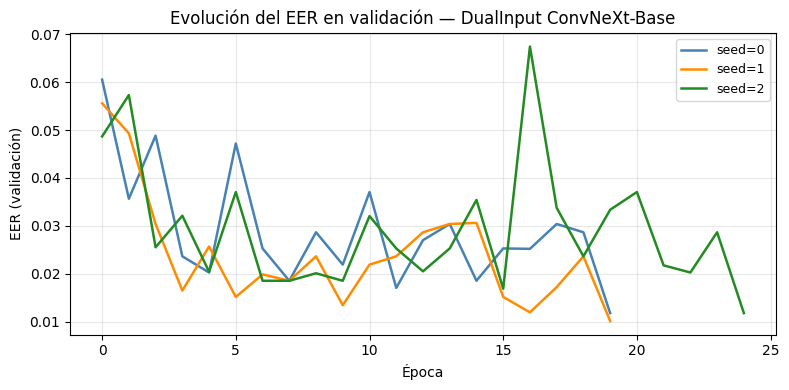

Curva guardada: /content/drive/MyDrive/TFM_ID_Cards/hito3/incode_replica/training_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'darkorange', 'forestgreen']
for seed, color in zip(CONFIG['run_seeds'], colors):
    ckpt = CKPT_DIR / f'best_run{seed}.pt'
    if not ckpt.exists(): continue
    state = torch.load(str(ckpt), map_location='cpu', weights_only=False)
    hist  = state.get('history', {})
    if 'val_eer' in hist and hist['val_eer']:
        ax.plot(hist['val_eer'], color=color, lw=1.8, label=f'seed={seed}')
ax.set_xlabel('Época'); ax.set_ylabel('EER (validación)')
ax.set_title('Evolución del EER en validación — DualInput ConvNeXt-Base')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = OUTPUT_DIR / 'training_curves.png'
fig.savefig(str(fig_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Curva guardada: {fig_path}')


## Resultados y limitaciones de la réplica

Este cuaderno replica los tres componentes del enfoque Incode que son reproducibles con datos públicos: la clasificación multilabel con cuatro cabezas sigmoid, la entrada dual con distintos niveles de contexto, y la función de puntuación S = clamp(½(P_bonafide − max P_ataques + 1), 0, 1). Los resultados permiten cuantificar en qué medida esas decisiones de diseño explican la ventaja observada frente a los modelos softmax convencionales del Hito 2.

Existen dos diferencias estructurales inevitables entre esta réplica y el sistema original. Los datos sintéticos SPAS generados con FLUX Klein 9B no están disponibles públicamente, de modo que el conjunto de entrenamiento es más pequeño. Además, Incode construyó un ensemble sobre cinco folds de la partición privada del challenge, lo que mejora el rendimiento pero no es reproducible sin acceso a esa partición. Por tanto, cualquier diferencia entre los números de esta réplica y los del reto oficial refleja en parte la ausencia de esos componentes, no solo una diferencia en la arquitectura.